In [464]:
# libraries
import pandas as pd
import numpy as np
import cv2 as cv
import torch
import torch.nn as nn
import torch.optim as optim

In [465]:
import os 

def im_to_array(path, size=(128,128)):
    im_list = []
    for filename in os.listdir(path):
        if filename.endswith('.jpg'):
            im = cv.imread(os.path.join(path, filename), cv.IMREAD_GRAYSCALE)
            im = cv.resize(im, size) 
            im = im/255.0                       
            im_list.append(im.flatten()) 
    return np.array(im_list)

In [466]:
import os
folder = r"D:\ITC\Year3\I3 s2\Introduction_Machinlearning\Project\project4\Test\Dog"
print(os.listdir(folder))


['dog (1).jpg', 'dog (10).jpg', 'dog (11).jpg', 'dog (12).jpg', 'dog (13).jpg', 'dog (14).jpg', 'dog (15).jpg', 'dog (16).jpg', 'dog (17).jpg', 'dog (18).jpg', 'dog (19).jpg', 'dog (2).jpg', 'dog (21).jpg', 'dog (3).jpg', 'dog (4).jpg', 'dog (5).jpg', 'dog (6).jpg', 'dog (7).jpg', 'dog (8).jpg', 'dog (9).jpg']


In [467]:
# using cv reading an image
im_test_dog = cv.imread("D:\\ITC\\Year3\\I3 s2\\Introduction_Machinlearning\\Project\\project4\\Test\\Dog\\dog (1).jpg", cv.IMREAD_GRAYSCALE)
print(im_test_dog.shape)

im_test_cat = cv.imread("D:\\ITC\\Year3\\I3 s2\\Introduction_Machinlearning\\Project\\project4\\Test\\Cat\\cat (1).jpg", cv.IMREAD_GRAYSCALE)
print(im_test_cat.shape)

(1280, 960)
(1280, 720)


In [468]:
im_train_dog = im_to_array(r"D:\ITC\Year3\I3 s2\Introduction_Machinlearning\Project\project4\Train\Dog")
y_train_dog = np.ones(im_train_dog.shape[0])

im_train_cat = im_to_array(r"D:\ITC\Year3\I3 s2\Introduction_Machinlearning\Project\project4\Train\Cat")
y_train_cat = np.zeros(im_train_cat.shape[0])

X_train = np.concatenate((im_train_dog, im_train_cat), axis=0)
y_train = np.concatenate((y_train_dog, y_train_cat), axis=0)

print(X_train.shape)
print(y_train.shape)




(161, 16384)
(161,)


# Test

In [469]:
im_test_dog = im_to_array(r"D:\ITC\Year3\I3 s2\Introduction_Machinlearning\Project\project4\Test\Dog")
y_test_dog = np.ones(im_test_dog.shape[0])

im_test_cat = im_to_array(r"D:\ITC\Year3\I3 s2\Introduction_Machinlearning\Project\project4\Test\Cat")
y_test_cat = np.zeros(im_test_cat.shape[0])

X_test = np.concatenate((im_test_dog, im_test_cat), axis=0)
y_test = np.concatenate((y_test_dog, y_test_cat), axis=0)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print(X_test.shape)
print(y_test.shape)


(40, 16384)
(40,)


In [470]:
# Save x and y
np.save("X_train.npy",X_train)
np.save("y_train.npy",y_train)

In [471]:

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

print(X_train_tensor.shape)
print(y_train_tensor.shape)

torch.Size([161, 16384])
torch.Size([161])


In [472]:
# define model
def my_ANN (X, w1,b1,w2,b2,w3,b3):
    # layer 1
    Z1 = torch.matmul(X,w1) + b1
    A1 = torch.relu(Z1)
    # layer 2
    Z2 = torch.matmul(A1,w2) + b2
    A2 = torch.relu(Z2)
    # layer 3
    Z3 = torch.matmul(A2,w3) + b3
    return Z3

In [473]:
# Training
W1 = torch.randn(16384,128, requires_grad= True)
b1 = torch.zeros(1, 128, requires_grad= True)
W2 = torch.randn(128, 64, requires_grad =True)
b2 = torch.zeros(1, 64, requires_grad= True)
W3 = torch.randn(64, 2, requires_grad= True)
b3 = torch.zeros(1, 2, requires_grad= True)

cost_func = nn.CrossEntropyLoss()
optimizer = optim.SGD([W1,b1,W2,b2,W3,b3], lr=0.01)

for epoch in range(1, 201):
    Z = my_ANN(X_train_tensor, W1, b1, W2, b2, W3, b3)
    loss = cost_func(Z, y_train_tensor)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    print(f"Epoch: {epoch:03d}, Loss: {loss.item():.4f}")

Epoch: 001, Loss: 698.3942
Epoch: 002, Loss: 36744.3906
Epoch: 003, Loss: 9264.6133
Epoch: 004, Loss: 407.1952
Epoch: 005, Loss: 7892.0107
Epoch: 006, Loss: 1075.9208
Epoch: 007, Loss: 1570.8264
Epoch: 008, Loss: 9113.2871
Epoch: 009, Loss: 80.5671
Epoch: 010, Loss: 16.0220
Epoch: 011, Loss: 9.4778
Epoch: 012, Loss: 7.6494
Epoch: 013, Loss: 4.4736
Epoch: 014, Loss: 3.8175
Epoch: 015, Loss: 2.5104
Epoch: 016, Loss: 2.0152
Epoch: 017, Loss: 1.5188
Epoch: 018, Loss: 1.2181
Epoch: 019, Loss: 1.3067
Epoch: 020, Loss: 1.2265
Epoch: 021, Loss: 1.1286
Epoch: 022, Loss: 1.1597
Epoch: 023, Loss: 1.0899
Epoch: 024, Loss: 1.1149
Epoch: 025, Loss: 0.8591
Epoch: 026, Loss: 1.0081
Epoch: 027, Loss: 0.9448
Epoch: 028, Loss: 0.8605
Epoch: 029, Loss: 1.0376
Epoch: 030, Loss: 0.7255
Epoch: 031, Loss: 0.7391
Epoch: 032, Loss: 0.9816
Epoch: 033, Loss: 0.7189
Epoch: 034, Loss: 0.8644
Epoch: 035, Loss: 0.9875
Epoch: 036, Loss: 0.8431
Epoch: 037, Loss: 0.9065
Epoch: 038, Loss: 0.7994
Epoch: 039, Loss: 0.8683


In [474]:
# Evaluate
Z= my_ANN(X_train_tensor, W1, b1, W2, b2, W3, b3)
y_pred = torch.argmax(Z,dim=1)
acc = torch.mean((y_pred == y_train_tensor).float())
print(f"Accuracy: {acc*100:.2f}%")

Accuracy: 59.01%


In [475]:
cost_func = nn.CrossEntropyLoss()
optimizer = optim.SGD([W1,b1,W2,b2,W3,b3], lr=0.01)

for epoch in range(1, 201):
    Z = my_ANN(X_test_tensor, W1, b1, W2, b2, W3, b3)
    loss = cost_func(Z, y_test_tensor)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    print(f"Epoch: {epoch:03d}, Loss: {loss.item():.4f}")

Epoch: 001, Loss: 13.2324
Epoch: 002, Loss: 1.3922
Epoch: 003, Loss: 0.6153
Epoch: 004, Loss: 0.6139
Epoch: 005, Loss: 0.6128
Epoch: 006, Loss: 0.6119
Epoch: 007, Loss: 0.6112
Epoch: 008, Loss: 0.6106
Epoch: 009, Loss: 0.6102
Epoch: 010, Loss: 0.6098
Epoch: 011, Loss: 0.6095
Epoch: 012, Loss: 0.6092
Epoch: 013, Loss: 0.6090
Epoch: 014, Loss: 0.6088
Epoch: 015, Loss: 0.6086
Epoch: 016, Loss: 0.6084
Epoch: 017, Loss: 0.6082
Epoch: 018, Loss: 0.6081
Epoch: 019, Loss: 0.6080
Epoch: 020, Loss: 0.6079
Epoch: 021, Loss: 0.6078
Epoch: 022, Loss: 0.6077
Epoch: 023, Loss: 0.6076
Epoch: 024, Loss: 0.6076
Epoch: 025, Loss: 0.6075
Epoch: 026, Loss: 0.6074
Epoch: 027, Loss: 0.6074
Epoch: 028, Loss: 0.6073
Epoch: 029, Loss: 0.6073
Epoch: 030, Loss: 0.6073
Epoch: 031, Loss: 0.6072
Epoch: 032, Loss: 0.6072
Epoch: 033, Loss: 0.6071
Epoch: 034, Loss: 0.6071
Epoch: 035, Loss: 0.6071
Epoch: 036, Loss: 0.6071
Epoch: 037, Loss: 0.6070
Epoch: 038, Loss: 0.6070
Epoch: 039, Loss: 0.6070
Epoch: 040, Loss: 0.6070

In [476]:
Z = my_ANN(X_test_tensor, W1, b1, W2, b2, W3, b3)
y_pred = torch.argmax(Z, dim=1)
acc = torch.mean((y_pred == y_test_tensor).float())
print(f"Accuracy: {acc*100:.2f}%")


Accuracy: 57.50%


In [477]:
print(f"Train range: {X_train_tensor.min():.4f} to {X_train_tensor.max():.4f}")
print(f"Test range:  {X_test_tensor.min():.4f} to {X_test_tensor.max():.4f}")

Train range: 0.0000 to 1.0000
Test range:  0.0000 to 1.0000


Prediction : Dog (50.7% confident)
Confidence : Cat 49.3% | Dog 50.7%


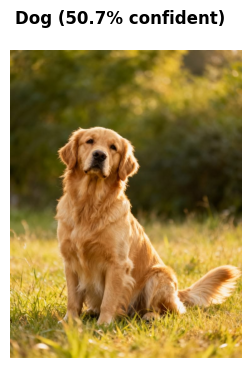

In [486]:
import matplotlib.pyplot as plt

def predict_image(image_path, size=(128, 128)):

    img_color = cv.imread(image_path)
    img_color = cv.cvtColor(img_color, cv.COLOR_BGR2RGB)


    im = cv.imread(image_path, cv.IMREAD_GRAYSCALE)
    im = cv.resize(im, size)
    im = im / 255.0
    im = im.flatten()
    
    tensor = torch.tensor(im, dtype=torch.float32).unsqueeze(0)


    with torch.no_grad():
        output = my_ANN(tensor, W1, b1, W2, b2, W3, b3)
        _, predicted = torch.max(output, 1)
        confidence = torch.softmax(output, dim=1)

    cat_conf = confidence[0][0].item() * 100
    dog_conf = confidence[0][1].item() * 100

    if predicted.item() == 0:
        label = f"Cat ({cat_conf:.1f}% confident)"
    else:
        label = f"Dog ({dog_conf:.1f}% confident)"

    print(f"Prediction : {label}")
    print(f"Confidence : Cat {cat_conf:.1f}% | Dog {dog_conf:.1f}%")


    plt.figure(figsize=(4, 4))
    plt.suptitle(label, fontsize=12, weight="bold")
    plt.imshow(img_color)   
    plt.axis("off")
    plt.xlabel(f"Cat {cat_conf:.1f}% | Dog {dog_conf:.1f}%")
    plt.show()

    return label

label = predict_image("D:/ITC/Year3/I3 s2/Introduction_Machinlearning/Project/project4/example/15.jpg")

In [479]:
# Save new weights after good training
torch.save({
    "W1": W1.detach(), "b1": b1.detach(),
    "W2": W2.detach(), "b2": b2.detach(),
    "W3": W3.detach(), "b3": b3.detach()
}, r"D:\ITC\Year3\I3 s2\Introduction_Machinlearning\Project\project4\weights.pth")
